<a href="https://colab.research.google.com/github/GyanAnargya/Kumpulan-Hasil-Tugas-Besar/blob/main/TUBES_AI_LIVER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TUBES AI DATASET LIVER

KELOMPOK: 9

NAMA ANGGOTA:
- MUHAMMAD ABIDZAR AKROM 101052300089
- REVINA AGNANTA 101052300014

## **MODEL MACHINE LEARNING LOGISTIC REGRESSION**

### **IMPORT LIBRARIES**

In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier

**MOUNT GOOGLE DRIVE**

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LOAD DATASET

In [ ]:
# load dataset
data = pd.read_csv('/content/drive/MyDrive/Liver/liver_patient.csv')
df = data.copy()

# 1. Overview
print("First 5 rows of the dataset:")
print(df.head())
print("\nData shape:", df.shape)
print("\nAvailable column names:", df.columns.tolist())
print("\nClass distribution:")
if 'Dataset' in df.columns:
    print(df['Dataset'].value_counts())
else:
    print("\n'Dataset' column not found in the DataFrame. Please check the column names.")

print("\nFeature Summary:")
print(df.describe())

First 5 rows of the dataset:
   Age     Sex  Total_Bilirubin_Level  Bilirubin_Direct  Alp_Level  Alt_Level  \
0   65  Female                    0.7               0.1        187         16   
1   62    Male                   10.9               5.5        699         64   
2   62    Male                    7.3               4.1        490         60   
3   58    Male                    1.0               0.4        182         14   
4   72    Male                    3.9               2.0        195         27   

   Ast_Level  Protein_Total  Albumin  AG_Ratio  Dataset  
0         18            6.8      3.3      0.90        1  
1        100            7.5      3.2      0.74        1  
2         68            7.0      3.3      0.89        1  
3         20            6.8      3.4      1.00        1  
4         59            7.3      2.4      0.40        1  

Data shape: (583, 11)

Available column names: ['Age', 'Sex', 'Total_Bilirubin_Level', 'Bilirubin_Direct', 'Alp_Level', 'Alt_Level', 'A

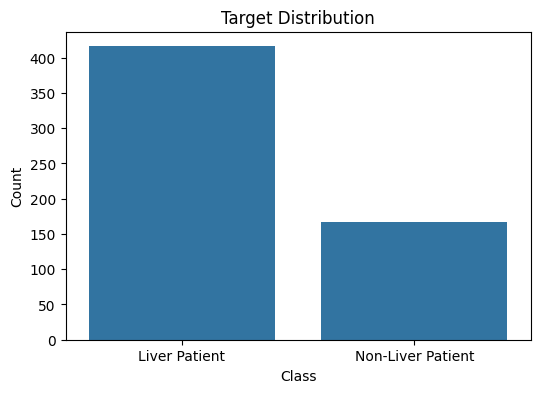

In [ ]:
# 2. Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Dataset', data=df)
plt.xticks([0, 1], ['Liver Patient', 'Non-Liver Patient'])
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

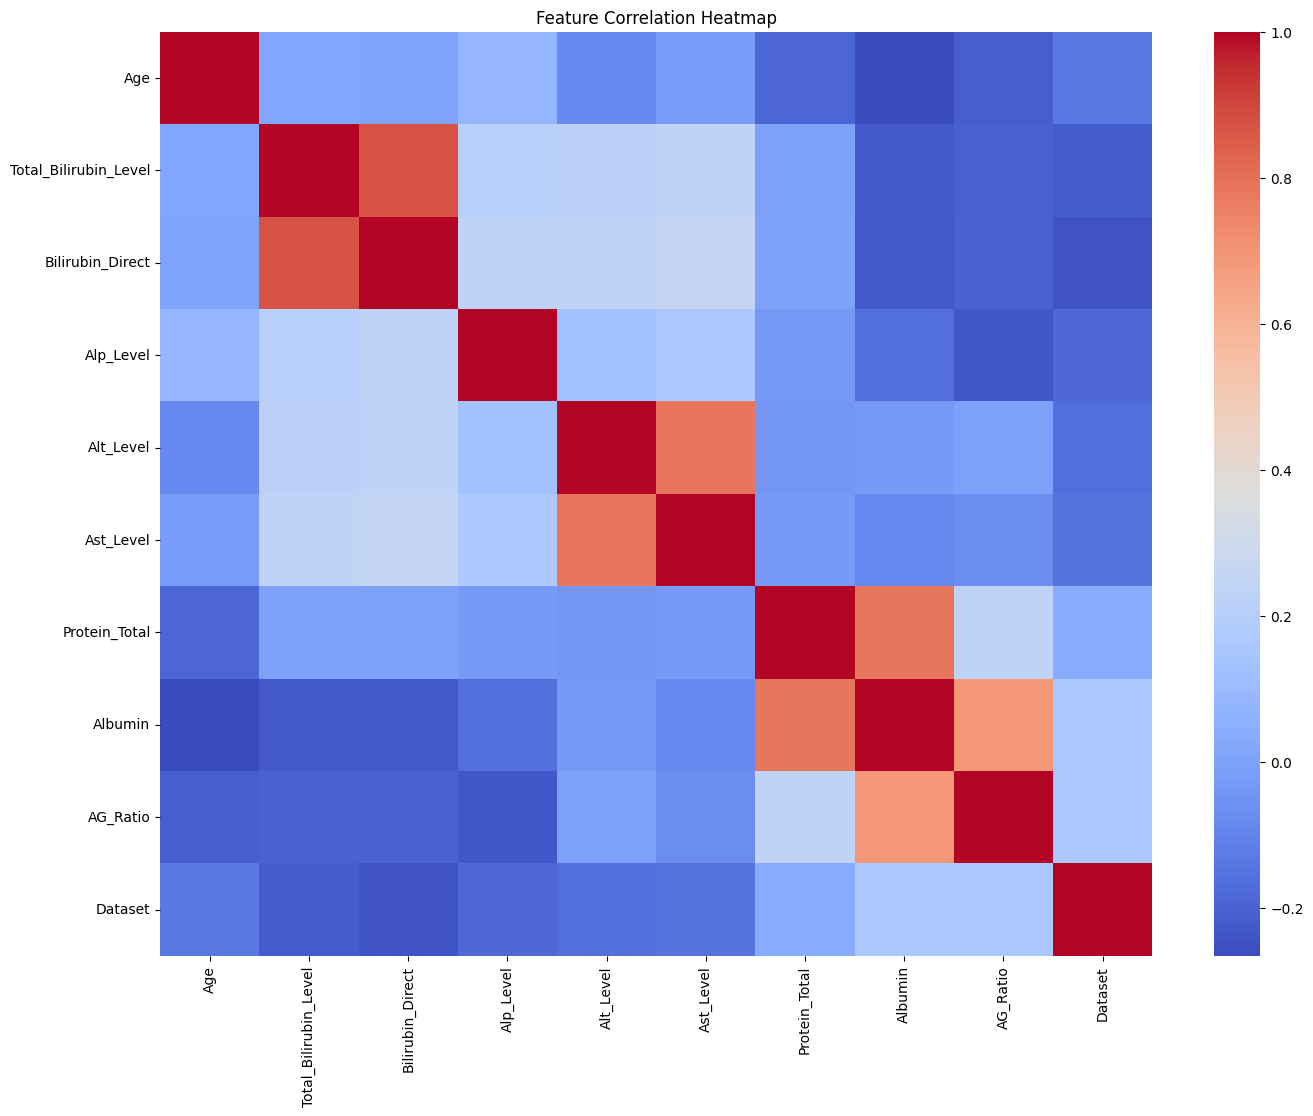

In [ ]:
# 3. Correlation Heatmap
plt.figure(figsize=(16, 12))
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# 4. Top 5 features most correlated with the target
top_corr = corr_matrix['Dataset'].abs().sort_values(ascending=False)[1:6]
top_features = top_corr.index.tolist()
if 'Dataset' in corr_matrix.columns:
    corr_with_target = corr_matrix['Dataset'].abs().sort_values(ascending=False)
    corr_with_target = corr_with_target.drop('Dataset')
    top_corr = corr_with_target.head(5)

    top_features = top_corr.index.tolist()
    print("\nTop 5 features most correlated with 'Dataset':", top_features)

else:
    print("\n'Dataset' column not found in correlation matrix. Cannot determine top correlated features.")
    top_features = []


Top 5 features most correlated with 'Dataset': ['Bilirubin_Direct', 'Total_Bilirubin_Level', 'Alp_Level', 'Alt_Level', 'AG_Ratio']


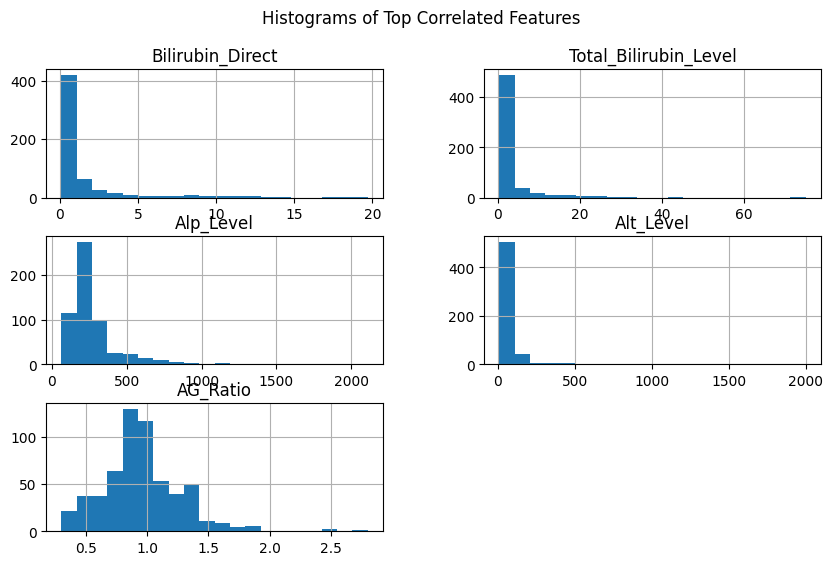

In [ ]:
# 5. Histograms of top correlated features
if top_features:
    df[top_features].hist(bins=20, figsize=(10, 6))
    plt.suptitle("Histograms of Top Correlated Features")
    plt.show()
else:
    print("\nCannot plot histograms: No top correlated features identified.")

# histogram dari top features

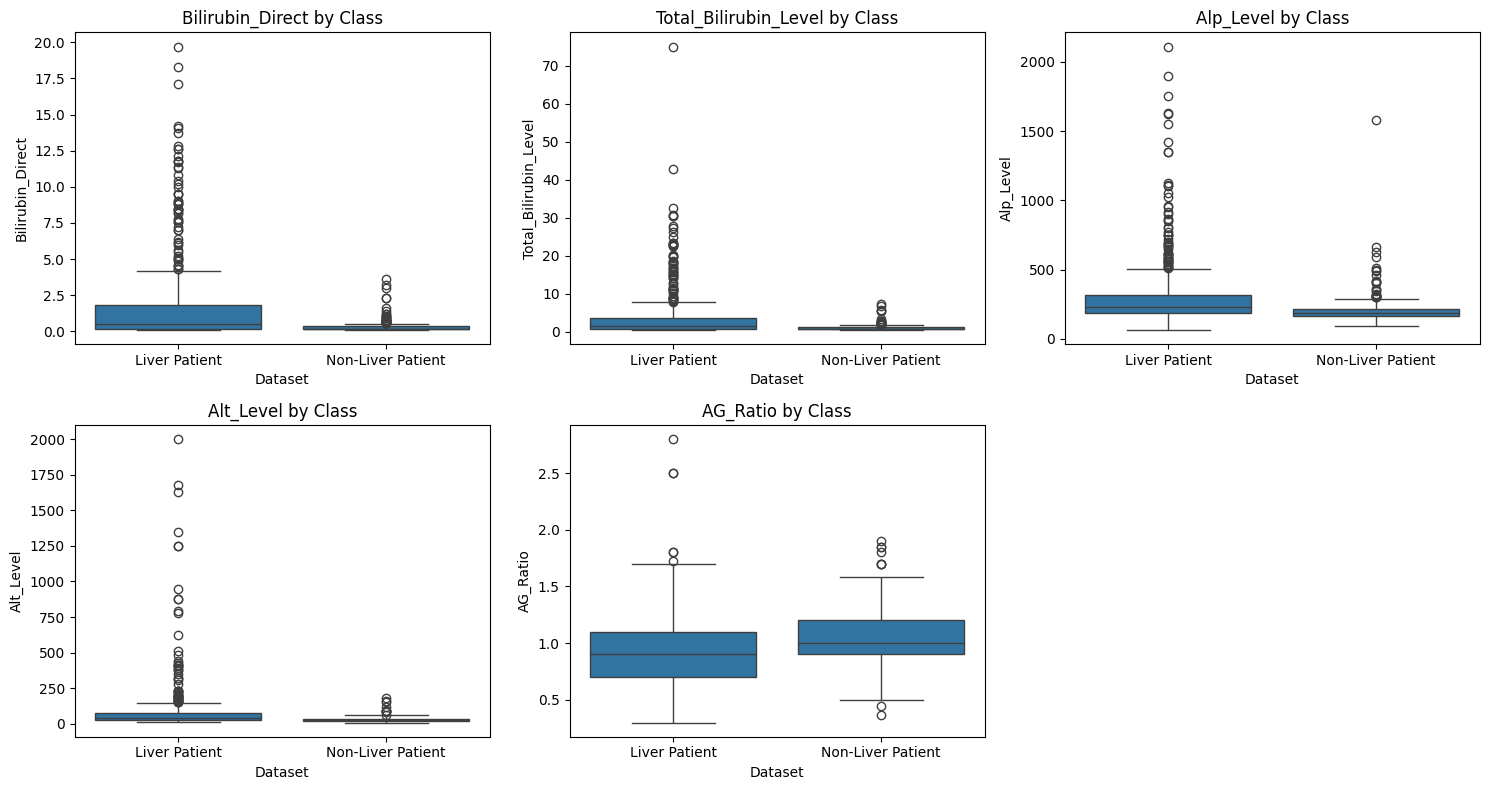

In [ ]:
# 6. Boxplots by target class
plt.figure(figsize=(15, 8))
for i, feature in enumerate(top_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Dataset', y=feature, data=df)
    plt.title(f"{feature} by Class")
    plt.xticks([0, 1], ['Liver Patient', 'Non-Liver Patient'])
plt.tight_layout()
plt.show()

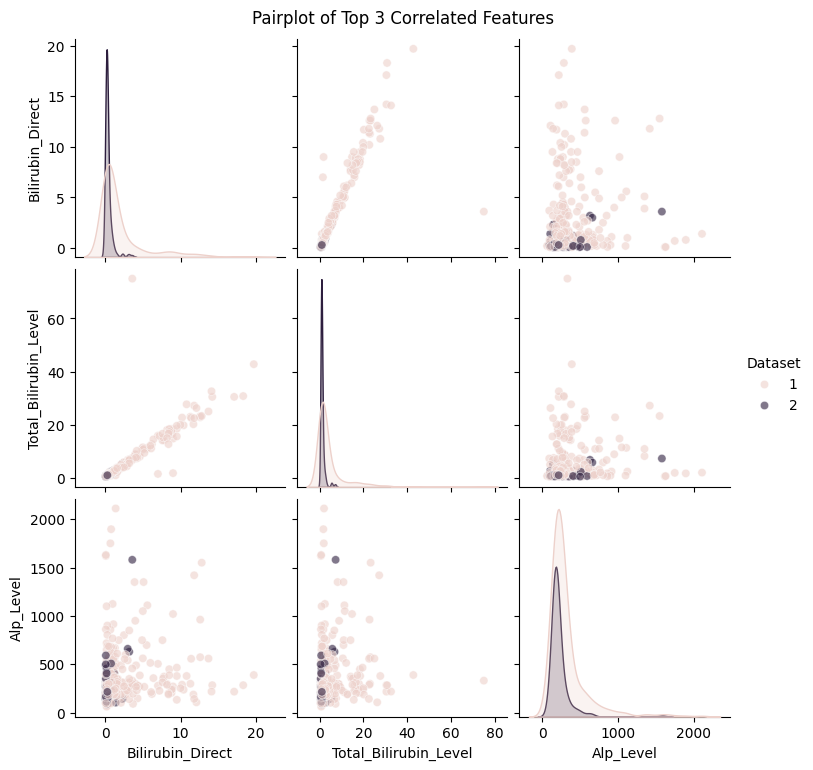

In [ ]:
# 7. Pairplot of top 3 features
sns.pairplot(df, vars=top_features[:3], hue='Dataset', plot_kws={'alpha': 0.6})
plt.suptitle("Pairplot of Top 3 Correlated Features", y=1.02)
plt.show()

**LOAD DATASET (TRAIN, TEST)**

In [ ]:
# load dataset
X = df.drop('Dataset', axis=1)
y = df['Dataset']

y = y.map({1: 0, 2: 1})

# 1. Encoding Variabel Categorical
if X['Sex'].dtype == 'object':
    print("Encoding 'Sex' column...")
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    X['Sex'] = le.fit_transform(X['Sex'])
    print("'Sex' column encoded.")
else:
    print("'Sex' column is already numeric.")

print("\nChecking for and imputing missing values...")
from sklearn.impute import SimpleImputer
numeric_cols_for_imputation = X.select_dtypes(include=np.number).columns.tolist()
imputer = SimpleImputer(strategy='mean')

X[numeric_cols_for_imputation] = imputer.fit_transform(X[numeric_cols_for_imputation])

print("Missing values imputed (using mean strategy).")
print("Checking for remaining NaNs in X after imputation:", X.isnull().sum().sum())

Encoding 'Sex' column...
'Sex' column encoded.

Checking for and imputing missing values...
Missing values imputed (using mean strategy).
Checking for remaining NaNs in X after imputation: 0


In [ ]:
# 2. Pembagian Data menjadi Training dan Testing Set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Target distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Target distribution in testing set:\n{y_test.value_counts(normalize=True)}")


Training set shape: (466, 10)
Testing set shape: (117, 10)
Target distribution in training set:
Dataset
0    0.708155
1    0.291845
Name: proportion, dtype: float64
Target distribution in testing set:
Dataset
0    0.735043
1    0.264957
Name: proportion, dtype: float64


In [ ]:
# 3. Scaling Fitur Numerik
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print(f"\nNumeric columns for scaling: {numeric_cols}")

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nFeatures scaled.")


Numeric columns for scaling: ['Age', 'Sex', 'Total_Bilirubin_Level', 'Bilirubin_Direct', 'Alp_Level', 'Alt_Level', 'Ast_Level', 'Protein_Total', 'Albumin', 'AG_Ratio']

Features scaled.


In [ ]:
# 4. Inisialisasi dan Pelatihan Model logistic regression
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=42)

print("\nTraining Logistic Regression model...")
model_lr.fit(X_train, y_train)
print("Model training complete.")


Training Logistic Regression model...
Model training complete.


In [ ]:
# 5. Prediksi pada Testing Set
y_pred = model_lr.predict(X_test)

# 6. Evaluasi Model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("\nModel Evaluation:")
accuracy_lr = accuracy_score(y_test, y_pred)
conf_matrix_lr = confusion_matrix(y_test, y_pred)
class_report_lr = classification_report(y_test, y_pred, output_dict=True)

print("Accuracy:", accuracy_lr)
print("\nConfusion Matrix:")
print(conf_matrix_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation:
Accuracy: 0.7435897435897436

Confusion Matrix:
[[83  3]
 [27  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.97      0.85        86
           1       0.57      0.13      0.21        31

    accuracy                           0.74       117
   macro avg       0.66      0.55      0.53       117
weighted avg       0.71      0.74      0.68       117



In [ ]:
# 7. Store results
results = []

model_name_lr = "Logistic Regression"
model_results_lr = {
    'Model': model_name_lr,
    'Accuracy': accuracy_lr,
    'Confusion Matrix': conf_matrix_lr,
    'Precision (Weighted Avg)': class_report_lr['weighted avg']['precision'],
    'Recall (Weighted Avg)': class_report_lr['weighted avg']['recall'],
    'F1-Score (Weighted Avg)': class_report_lr['weighted avg']['f1-score']
}

results.append(model_results_lr)


--- Model Performance Summary ---
                 Model  Accuracy  Precision (Weighted Avg)  \
0  Logistic Regression   0.74359                  0.706027   

   Recall (Weighted Avg)  F1-Score (Weighted Avg)  
0                0.74359                 0.678317  

--- Confusion Matrix for Logistic Regression ---
[[83  3]
 [27  4]]

--- Plotting Confusion Matrix for Logistic Regression ---


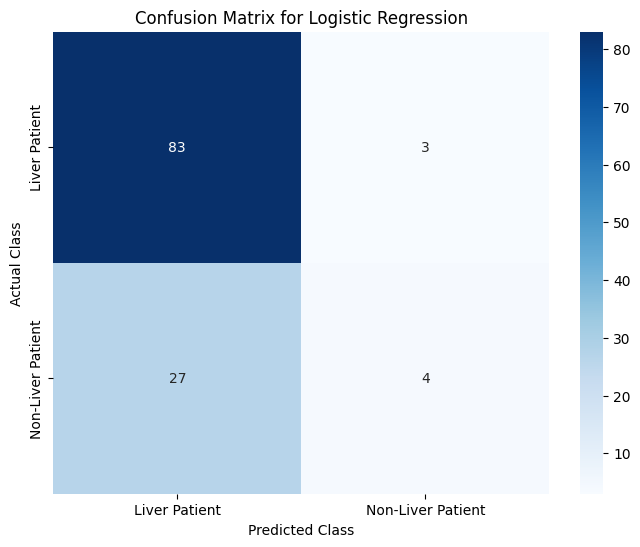

In [ ]:
# 8. Display results in a DataFrame
df_results = pd.DataFrame(results).drop(columns=['Confusion Matrix'])
if 'Model' in df_results.columns:
    cols = df_results.columns.tolist()
    cols.remove('Model')
    df_results = df_results[['Model'] + cols]

print("\n--- Model Performance Summary ---")
print(df_results)

print(f"\n--- Confusion Matrix for {model_name_lr} ---")
print(conf_matrix_lr)

# Plot confusion matrix
print(f"\n--- Plotting Confusion Matrix for {model_name_lr} ---")
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
class_labels = ['Liver Patient', 'Non-Liver Patient']
sns.heatmap(conf_matrix_lr,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title(f"Confusion Matrix for {model_name_lr}")
plt.show()


--- Generating ROC Curve for Logistic Regression ---


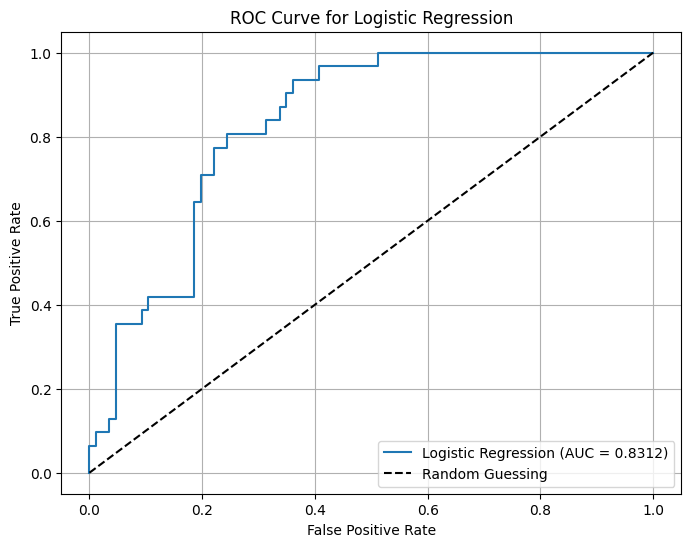


AUC Score for Logistic Regression: 0.8312


In [ ]:
# 9. ROC Curve and AUC (for Logistic Regression)
print(f"\n--- Generating ROC Curve for {model_name_lr} ---")

# Use y_pred_proba_lr which is the predicted probability for the positive class (class 1)
y_pred_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Calculate ROC curve
# fpr = False Positive Rate, tpr = True Positive Rate, thresholds = Threshold values
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)

# Calculate AUC (Area Under the ROC Curve)
auc_score_lr = roc_auc_score(y_test, y_pred_proba_lr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'{model_name_lr} (AUC = {auc_score_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for {model_name_lr}')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nAUC Score for {model_name_lr}: {auc_score_lr:.4f}")


--- Generating Precision-Recall Curve for Logistic Regression ---


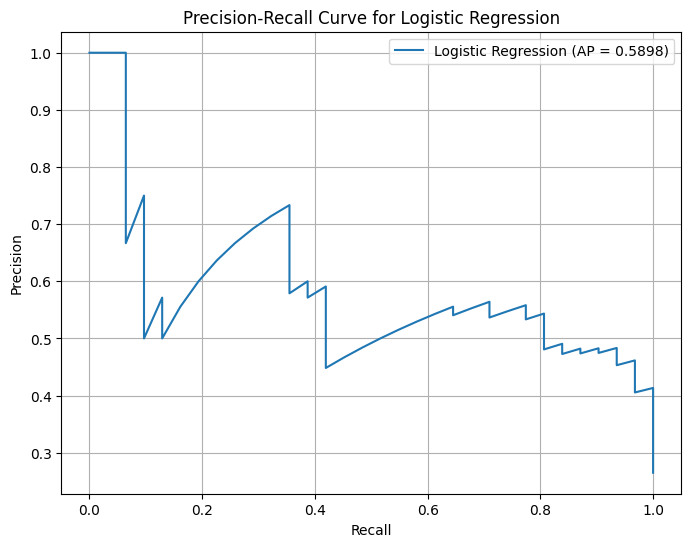


Average Precision (AP) Score for Logistic Regression: 0.5898

--- Feature Importance for Logistic Regression ---
                 Feature  Coefficient
5              Alt_Level    -1.397979
8                Albumin     0.950126
6              Ast_Level    -0.801626
7          Protein_Total    -0.797391
3       Bilirubin_Direct    -0.584660
4              Alp_Level    -0.351868
0                    Age    -0.288909
9               AG_Ratio    -0.226851
2  Total_Bilirubin_Level    -0.138434
1                    Sex     0.008253


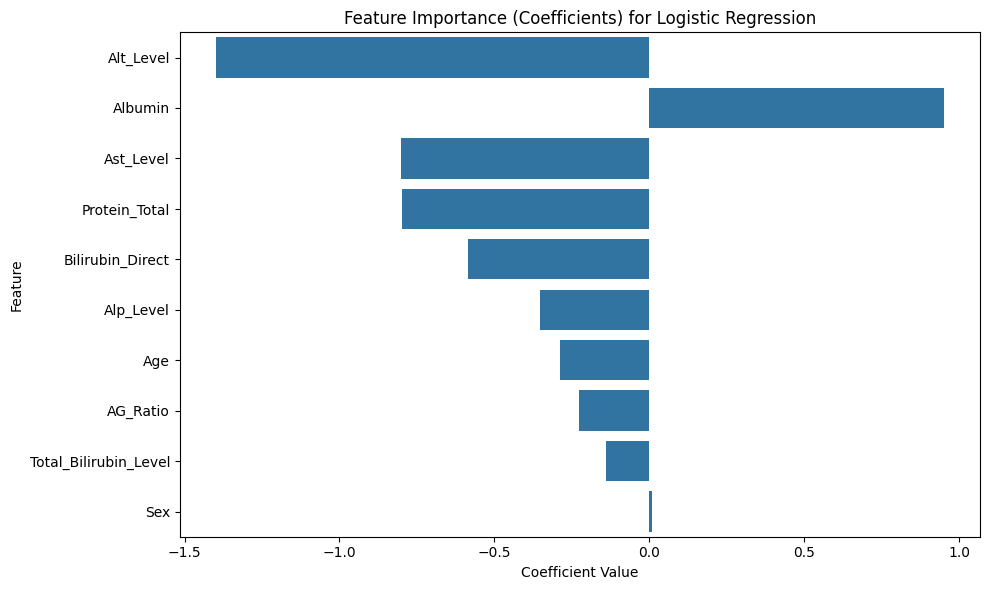

In [ ]:
# 10. Precision-Recall Curve (for Logistic Regression)
print(f"\n--- Generating Precision-Recall Curve for {model_name_lr} ---")

# Calculate Precision-Recall curve
# ADDED: Calculate precision, recall, and average_precision for LR
precision_lr, recall_lr, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_lr)
# Calculate Average Precision (Area Under Precision-Recall Curve)
average_precision_lr = average_precision_score(y_test, y_pred_proba_lr)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_lr, precision_lr, label=f'{model_name_lr} (AP = {average_precision_lr:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve for {model_name_lr}')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nAverage Precision (AP) Score for {model_name_lr}: {average_precision_lr:.4f}")

# 11. Feature Importance (for Logistic Regression)
print(f"\n--- Feature Importance for {model_name_lr} ---")

# Logistic Regression coefficients represent the feature importance (magnitude matters)
feature_names = X_train.columns
coefficients = model_lr.coef_[0]

# Create a DataFrame for easier sorting and visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by the absolute value of the coefficient
feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

# Print the sorted feature importance
print(feature_importance_df[['Feature', 'Coefficient']])

# Plotting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df)
plt.title(f'Feature Importance (Coefficients) for {model_name_lr}')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### MODEL GRADIENT BOOSTING


Training Gradient Boosting model...
Gradient Boosting model training complete.

Model Evaluation: Gradient Boosting
Accuracy: 0.7350427350427351

Confusion Matrix:
[[79  7]
 [24  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.92      0.84        86
           1       0.50      0.23      0.31        31

    accuracy                           0.74       117
   macro avg       0.63      0.57      0.57       117
weighted avg       0.70      0.74      0.70       117



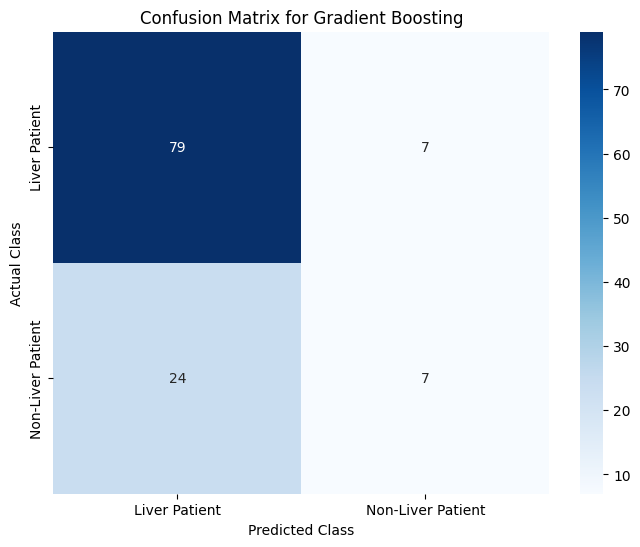

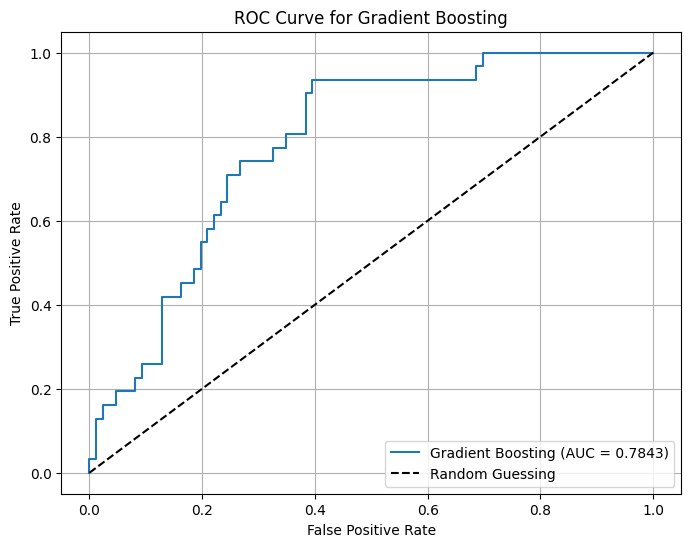

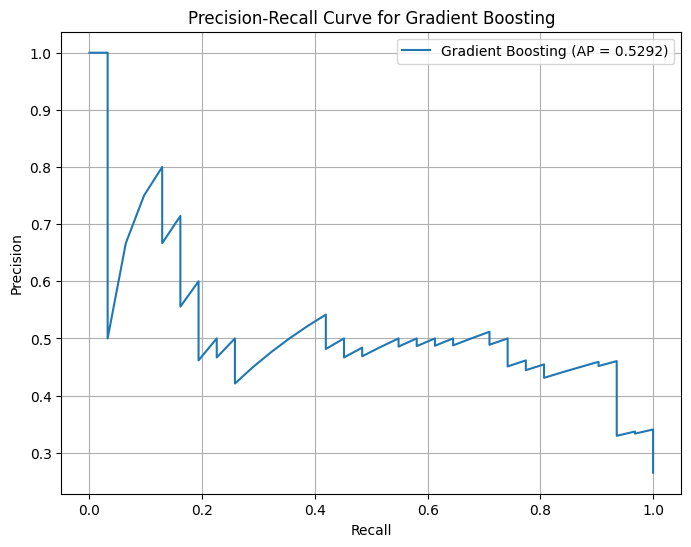


--- Feature Importance for Gradient Boosting ---
                 Feature  Importance
5              Alt_Level    0.222376
4              Alp_Level    0.187186
0                    Age    0.160696
6              Ast_Level    0.093045
9               AG_Ratio    0.075927
8                Albumin    0.070421
2  Total_Bilirubin_Level    0.063447
3       Bilirubin_Direct    0.061894
7          Protein_Total    0.047162
1                    Sex    0.017847


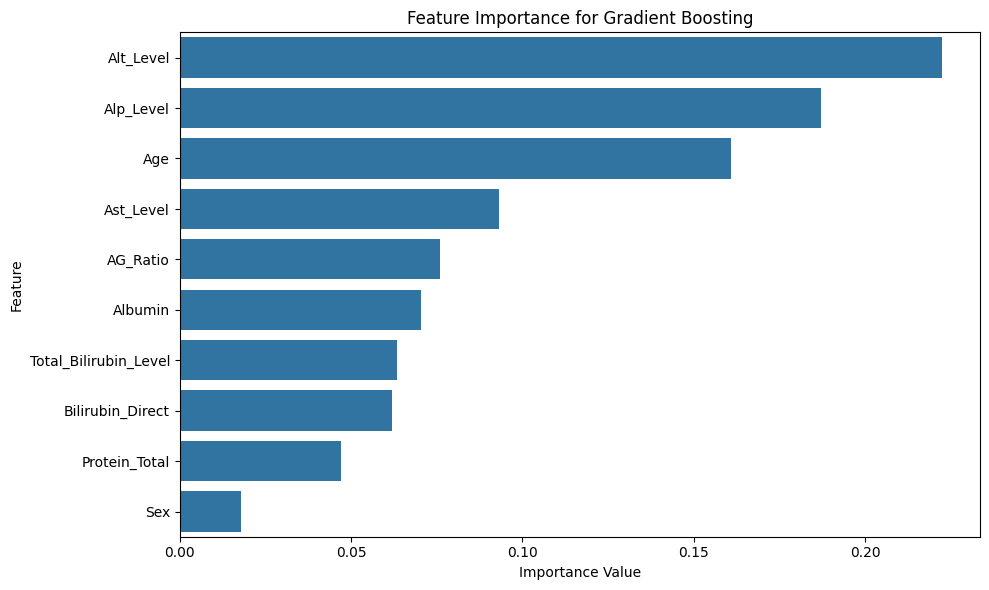

In [ ]:
# 1. Inisialisasi dan Pelatihan Model Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
model_gb = GradientBoostingClassifier(random_state=42) # Define Gradient Boosting model

print("\nTraining Gradient Boosting model...")
model_gb.fit(X_train, y_train) # Train the model
print("Gradient Boosting model training complete.")

# 2. Prediksi pada Testing Set
y_pred_gb = model_gb.predict(X_test) # Make predictions
y_pred_proba_gb = model_gb.predict_proba(X_test)[:, 1] # Get probabilities for AUC curves

# 3. Evaluasi Model Gradient Boosting
print("\nModel Evaluation: Gradient Boosting")
accuracy_gb = accuracy_score(y_test, y_pred_gb)
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
class_report_gb = classification_report(y_test, y_pred_gb, output_dict=True)

print("Accuracy:", accuracy_gb)
print("\nConfusion Matrix:")
print(conf_matrix_gb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

# 4. Store results for Gradient Boosting
model_name_gb = "Gradient Boosting"
model_results_gb = {
    'Model': model_name_gb,
    'Accuracy': accuracy_gb,
    'Confusion Matrix': conf_matrix_gb,
    'Precision (Weighted Avg)': class_report_gb['weighted avg']['precision'],
    'Recall (Weighted Avg)': class_report_gb['weighted avg']['recall'],
    'F1-Score (Weighted Avg)': class_report_gb['weighted avg']['f1-score']
}

# Calculate and store ROC AUC and PR AUC for GB
auc_score_gb = roc_auc_score(y_test, y_pred_proba_gb)
precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_pred_proba_gb)
average_precision_gb = average_precision_score(y_test, y_pred_proba_gb)

model_results_gb['ROC AUC'] = auc_score_gb
model_results_gb['PR AUC'] = average_precision_gb

results.append(model_results_gb) # Add Gradient Boosting results to the list

# Plot Confusion Matrix for GB
plt.figure(figsize=(8, 6))
class_labels = ['Liver Patient', 'Non-Liver Patient']
sns.heatmap(conf_matrix_gb,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title(f"Confusion Matrix for {model_name_gb}")
plt.show()

# Plot ROC Curve for GB
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, label=f'{model_name_gb} (AUC = {auc_score_gb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for {model_name_gb}')
plt.legend()
plt.grid(True)
plt.show()

# Plot Precision-Recall Curve for GB
plt.figure(figsize=(8, 6))
plt.plot(recall_gb, precision_gb, label=f'{model_name_gb} (AP = {average_precision_gb:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve for {model_name_gb}')
plt.legend()
plt.grid(True)
plt.show()

# Feature Importance for GB
print(f"\n--- Feature Importance for {model_name_gb} ---")
feature_importance_gb = model_gb.feature_importances_
feature_importance_df_gb = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance_gb})
feature_importance_df_gb = feature_importance_df_gb.sort_values(by='Importance', ascending=False)
print(feature_importance_df_gb)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_gb)
plt.title(f'Feature Importance for {model_name_gb}')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

PERBANDINGAN ANTARA MODEL ML (LR & GRADIENT BOOSTING)


--- Model Performance Summary ---
| Model               |   Accuracy |   Precision (Weighted Avg) |   Recall (Weighted Avg) |   F1-Score (Weighted Avg) |    ROC AUC |     PR AUC |
|:--------------------|-----------:|---------------------------:|------------------------:|--------------------------:|-----------:|-----------:|
| Logistic Regression |   0.74359  |                   0.706027 |                0.74359  |                  0.678317 | nan        | nan        |
| Gradient Boosting   |   0.735043 |                   0.696249 |                0.735043 |                  0.696911 |   0.784321 |   0.529185 |

--- Confusion Matrices ---

Confusion Matrix for Logistic Regression:
[[83  3]
 [27  4]]

Confusion Matrix for Gradient Boosting:
[[79  7]
 [24  7]]


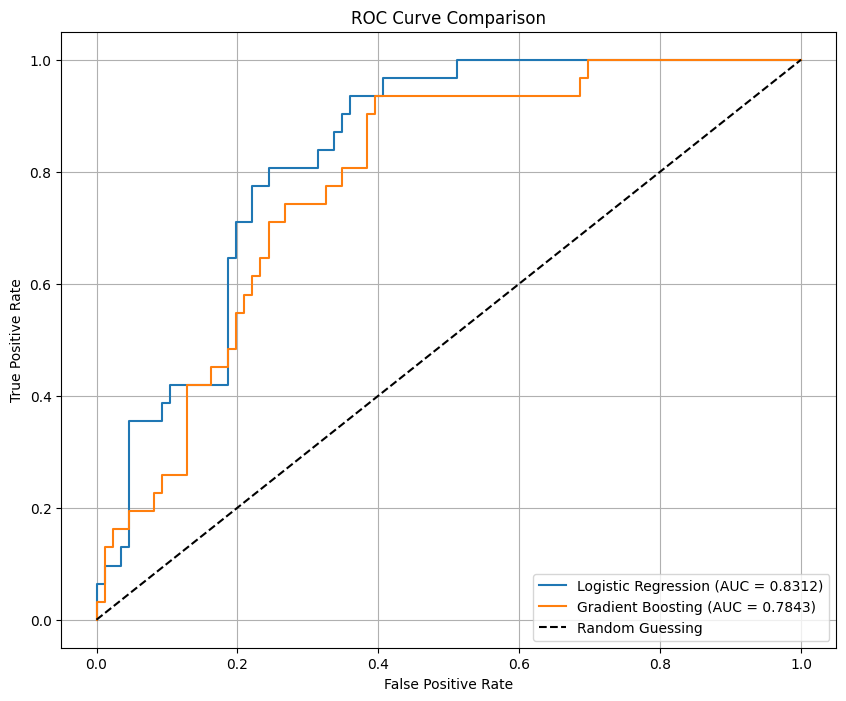

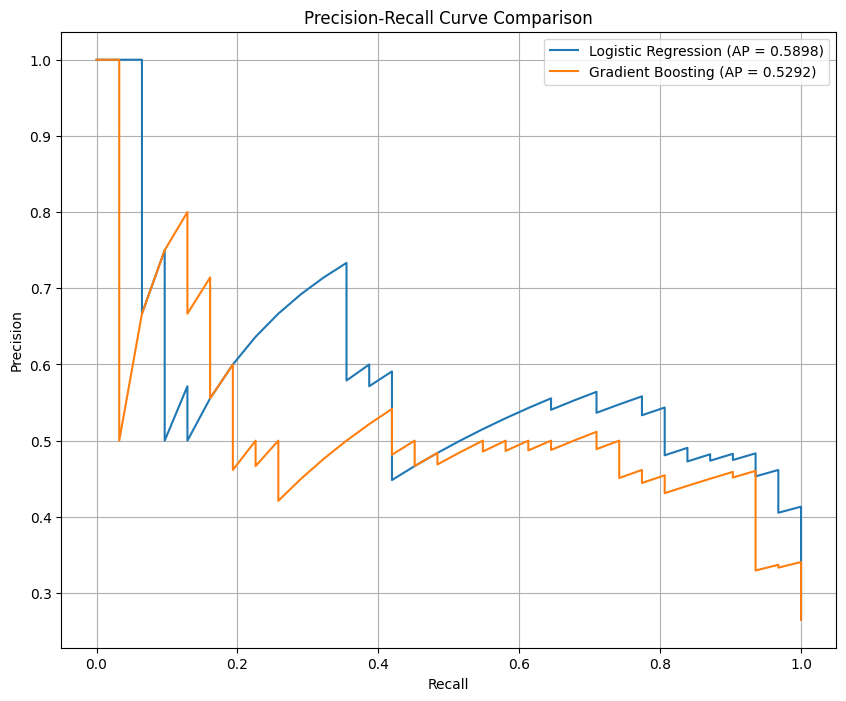

In [ ]:
# Display results in a DataFrame
df_results = pd.DataFrame(results)

# Drop Confusion Matrix column for cleaner comparison table
if 'Confusion Matrix' in df_results.columns:
    df_results = df_results.drop(columns=['Confusion Matrix'])

# Reorder columns if desired
cols = ['Model', 'Accuracy', 'Precision (Weighted Avg)', 'Recall (Weighted Avg)', 'F1-Score (Weighted Avg)', 'ROC AUC', 'PR AUC']
df_results = df_results[cols]

print("\n--- Model Performance Summary ---")
print(df_results.to_markdown(index=False)) # Use to_markdown for better printing in notebooks

# Display confusion matrices for all models
print("\n--- Confusion Matrices ---")
for res in results:
    print(f"\nConfusion Matrix for {res['Model']}:")
    print(res['Confusion Matrix'])

# Plotting ROC curves for comparison
plt.figure(figsize=(10, 8))
# Plot LR ROC
plt.plot(fpr_lr, tpr_lr, label=f'{model_name_lr} (AUC = {auc_score_lr:.4f})')
# Plot GB ROC
plt.plot(fpr_gb, tpr_gb, label=f'{model_name_gb} (AUC = {auc_score_gb:.4f})')


plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Precision-Recall curves for comparison
plt.figure(figsize=(10, 8))
# Plot LR PR
plt.plot(recall_lr, precision_lr, label=f'{model_name_lr} (AP = {average_precision_lr:.4f})')
# Plot GB PR
plt.plot(recall_gb, precision_gb, label=f'{model_name_gb} (AP = {average_precision_gb:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()